In [2]:
# ============================================================
# Step7 setup: load Step6 output JSON from Google Drive zip
# ============================================================

import json
import zipfile
import shutil
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive


# ------------------------------------------------------------
# 1. Mount Google Drive
# ------------------------------------------------------------

drive.mount("/content/drive")


# ------------------------------------------------------------
# 2. Step6 output zip path on Google Drive
# ------------------------------------------------------------

DRIVE_STEP6_ZIP_PATH = Path(
    "/content/drive/MyDrive/Colab Notebooks/linear_probe_pilot4/"
    "expB_settingA1_6fps/setting_synthetic/"
    "data_synthetic_disorder_lrab_2500/"
    "pilot4_synthetic_disorder_lrab_2500_implicit_transitive_probe_Qwen2_5_0_5B_step6_outputs.zip"
)

if not DRIVE_STEP6_ZIP_PATH.exists():
    raise FileNotFoundError(f"Step6 zip not found:\n{DRIVE_STEP6_ZIP_PATH}")

print("Found Step6 output zip:")
print(DRIVE_STEP6_ZIP_PATH)


# ------------------------------------------------------------
# 3. Extract Step6 zip locally
# ------------------------------------------------------------

STEP7_ROOT = Path("/content/pilot4_step7_lrab_2500")
STEP6_EXTRACT_DIR = STEP7_ROOT / "step6_extracted"
PLOT_OUTPUT_DIR = STEP7_ROOT / "step7_layerwise_plots"

if STEP6_EXTRACT_DIR.exists():
    shutil.rmtree(STEP6_EXTRACT_DIR)

if PLOT_OUTPUT_DIR.exists():
    shutil.rmtree(PLOT_OUTPUT_DIR)

STEP6_EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(DRIVE_STEP6_ZIP_PATH, "r") as zf:
    zf.extractall(STEP6_EXTRACT_DIR)

print("\nExtracted Step6 outputs to:")
print(STEP6_EXTRACT_DIR)


# ------------------------------------------------------------
# 4. Locate Step6 result JSON
# ------------------------------------------------------------

json_candidates = sorted(
    p for p in STEP6_EXTRACT_DIR.rglob("*.json")
    if "layer_diff_features" in p.name
)

if not json_candidates:
    print("\nVisible JSON files:")
    for p in sorted(STEP6_EXTRACT_DIR.rglob("*.json")):
        print("-", p)
    raise FileNotFoundError(
        "No Step6 layer_diff_features JSON found inside extracted zip."
    )

# Prefer the main full result JSON, not summary JSON if both exist.
main_json_candidates = [
    p for p in json_candidates
    if "summary" not in p.name.lower()
]

if main_json_candidates:
    RESULT_JSON_PATH = main_json_candidates[0]
else:
    RESULT_JSON_PATH = json_candidates[0]

print("\nUsing Step6 result JSON:")
print(RESULT_JSON_PATH)


# ------------------------------------------------------------
# 5. Load Step6 result JSON
# ------------------------------------------------------------

with open(RESULT_JSON_PATH, "r", encoding="utf-8") as f:
    payload = json.load(f)

results_by_layer = payload["results_by_layer"]

print("\nExperiment:", payload.get("experiment_name"))
print("Model:", payload.get("model_name"))
print("Feature key:", payload.get("feature_key"))
print("Num layers:", payload.get("num_layers"))
print("Num result layers:", len(results_by_layer))
print("Label order:", payload.get("label_order"))

print("\nPlot output directory:")
print(PLOT_OUTPUT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found Step6 output zip:
/content/drive/MyDrive/Colab Notebooks/linear_probe_pilot4/expB_settingA1_6fps/setting_synthetic/data_synthetic_disorder_lrab_2500/pilot4_synthetic_disorder_lrab_2500_implicit_transitive_probe_Qwen2_5_0_5B_step6_outputs.zip

Extracted Step6 outputs to:
/content/pilot4_step7_lrab_2500/step6_extracted

Using Step6 result JSON:
/content/pilot4_step7_lrab_2500/step6_extracted/step6_pilot4_synthetic_disorder_lrab_2500_implicit_transitive_probe_Qwen2_5_0_5B_layer_diff_features.json

Experiment: pilot4_synthetic_disorder_lrab_2500_implicit_transitive_probe
Model: Qwen/Qwen2.5-0.5B
Feature key: layer_diff_features
Num layers: 25
Num result layers: 25
Label order: ['above', 'below', 'left_of', 'right_of']

Plot output directory:
/content/pilot4_step7_lrab_2500/step7_layerwise_plots


In [3]:
# ============================================================
# Convert Step6 results into DataFrames
#   1. df: layer-level overall metrics
#   2. per_label_df: layer × subset × label metrics
# ============================================================

# ------------------------------------------------------------
# 1. Layer-level overall / rule-level metrics
# ------------------------------------------------------------

rows = []

for item in results_by_layer:
    layer = item["layer"]

    row = {
        "layer": layer,

        "train_accuracy": item["train"]["accuracy"],
        "train_macro_f1": item["train"]["macro_f1"],

        "test_overall_accuracy": item["test_overall"]["accuracy"],
        "test_overall_macro_f1": item["test_overall"]["macro_f1"],
    }

    for key, value in item.items():
        if key.startswith("test_rule_"):
            short_key = key.replace("test_rule_", "")
            row[f"{short_key}_accuracy"] = value["accuracy"]
            row[f"{short_key}_macro_f1"] = value["macro_f1"]
            row[f"{short_key}_num_examples"] = value["num_examples"]

    rows.append(row)

df = pd.DataFrame(rows).sort_values("layer").reset_index(drop=True)


# ------------------------------------------------------------
# 2. Per-layer per-label metrics
# ------------------------------------------------------------

if "per_layer_per_label_metrics" in payload:
    per_label_df = pd.DataFrame(payload["per_layer_per_label_metrics"])
else:
    # Fallback: reconstruct per-label metrics from results_by_layer.
    per_label_rows = []

    for item in results_by_layer:
        layer = item["layer"]

        for subset_name, eval_result in item.items():
            if subset_name == "layer":
                continue

            if not isinstance(eval_result, dict):
                continue

            if "classification_report" not in eval_result:
                continue

            report = eval_result["classification_report"]
            labels = eval_result.get("label_order", payload.get("label_order", []))

            for label in labels:
                if label not in report:
                    continue

                label_report = report[label]

                per_label_rows.append({
                    "layer": layer,
                    "subset": subset_name,
                    "label": label,
                    "precision": label_report.get("precision", 0.0),
                    "recall": label_report.get("recall", 0.0),
                    "f1": label_report.get("f1-score", 0.0),
                    "support": label_report.get("support", 0.0),

                    # If the old JSON does not have explicit per-label accuracy,
                    # use recall as true-class label accuracy.
                    "label_accuracy_true_class": label_report.get("recall", 0.0),
                    "one_vs_rest_accuracy": None,
                })

    per_label_df = pd.DataFrame(per_label_rows)


# ------------------------------------------------------------
# 3. Normalize column names
# ------------------------------------------------------------

if "f1-score" in per_label_df.columns and "f1" not in per_label_df.columns:
    per_label_df = per_label_df.rename(columns={"f1-score": "f1"})

required_cols = [
    "layer",
    "subset",
    "label",
    "precision",
    "recall",
    "f1",
    "support",
]

missing_cols = [c for c in required_cols if c not in per_label_df.columns]
if missing_cols:
    raise ValueError(f"per_label_df is missing columns: {missing_cols}")

per_label_df = per_label_df.sort_values(
    ["subset", "label", "layer"]
).reset_index(drop=True)


# ------------------------------------------------------------
# 4. Display
# ------------------------------------------------------------

pd.set_option("display.float_format", lambda x: f"{x:.6f}")

print("\nLayer-wise overall metrics:")
display(df.round(6))

print("\nPer-layer per-label metrics:")
display(per_label_df.head(40).round(6))

print("\nAvailable subsets in per_label_df:")
print(sorted(per_label_df["subset"].unique()))

print("\nAvailable labels in per_label_df:")
print(sorted(per_label_df["label"].unique()))


Layer-wise overall metrics:


,layer,train_accuracy,train_macro_f1,test_overall_accuracy,test_overall_macro_f1,anchor_between_reversed_surface_form_accuracy,anchor_between_reversed_surface_form_macro_f1,anchor_between_reversed_surface_form_num_examples,chain_same_direction_accuracy,chain_same_direction_macro_f1,chain_same_direction_num_examples,shared_anchor_opposite_sides_accuracy,shared_anchor_opposite_sides_macro_f1,shared_anchor_opposite_sides_num_examples
0,0,0.250000,0.100000,0.250000,0.100000,0.249624,0.099880,665,0.251121,0.100358,669,0.249249,0.099760,666
1,1,0.548125,0.546157,0.474000,0.471371,0.494737,0.492155,665,0.442451,0.440743,669,0.484985,0.481446,666
2,2,0.793000,0.793391,0.712500,0.712803,0.724812,0.725266,665,0.693572,0.693601,669,0.719219,0.718850,666
3,3,0.828250,0.828349,0.744000,0.744202,0.763910,0.763429,665,0.715994,0.716225,669,0.752252,0.752175,666
4,4,0.817500,0.817529,0.647000,0.647025,0.678195,0.678019,665,0.603886,0.603835,669,0.659159,0.658473,666
5,5,0.795750,0.795744,0.625000,0.625092,0.637594,0.637197,665,0.618834,0.618866,669,0.618619,0.618389,666
6,6,0.768250,0.768229,0.557500,0.557800,0.553383,0.552451,665,0.545590,0.545481,669,0.573574,0.573937,666
7,7,0.746125,0.746120,0.522000,0.522113,0.515789,0.514304,665,0.526158,0.526429,669,0.524024,0.524122,666
8,8,0.785125,0.785586,0.601000,0.601112,0.615038,0.613440,665,0.591928,0.593290,669,0.596096,0.595936,666
9,9,0.829250,0.829892,0.686500,0.688202,0.712782,0.713964,665,0.675635,0.677771,669,0.671171,0.672872,666



Per-layer per-label metrics:


,layer,subset,label,label_accuracy_true_class,one_vs_rest_accuracy,precision,recall,f1,support,tp,fp,fn,tn,total
0,0,test_overall,above,1.000000,0.250000,0.250000,1.000000,0.400000,500,500,1500,0,0,2000
1,1,test_overall,above,0.542000,0.752000,0.503717,0.542000,0.522158,500,271,267,229,1233,2000
2,2,test_overall,above,0.688000,0.872000,0.774775,0.688000,0.728814,500,344,100,156,1400,2000
3,3,test_overall,above,0.748000,0.884500,0.780793,0.748000,0.764045,500,374,105,126,1395,2000
4,4,test_overall,above,0.658000,0.828000,0.655378,0.658000,0.656687,500,329,173,171,1327,2000
5,5,test_overall,above,0.622000,0.820500,0.646570,0.622000,0.634047,500,311,170,189,1330,2000
6,6,test_overall,above,0.546000,0.773000,0.546000,0.546000,0.546000,500,273,227,227,1273,2000
7,7,test_overall,above,0.532000,0.774000,0.549587,0.532000,0.540650,500,266,218,234,1282,2000
8,8,test_overall,above,0.634000,0.823500,0.650924,0.634000,0.642351,500,317,170,183,1330,2000
9,9,test_overall,above,0.696000,0.881500,0.803695,0.696000,0.745981,500,348,85,152,1415,2000



Available subsets in per_label_df:
['test_overall', 'test_rule_anchor_between_reversed_surface_form', 'test_rule_chain_same_direction', 'test_rule_shared_anchor_opposite_sides', 'train']

Available labels in per_label_df:
['above', 'below', 'left_of', 'right_of']


In [4]:
# ------------------------------------------------------------
# 5. Best-layer summary
# ------------------------------------------------------------

best_acc_idx = df["test_overall_accuracy"].idxmax()
best_f1_idx = df["test_overall_macro_f1"].idxmax()

best_acc_row = df.loc[best_acc_idx]
best_f1_row = df.loc[best_f1_idx]

print("\nBest layer by test_overall_accuracy:")
print(
    f"layer={int(best_acc_row['layer'])} | "
    f"test_overall_accuracy={best_acc_row['test_overall_accuracy']:.6f} | "
    f"test_overall_macro_f1={best_acc_row['test_overall_macro_f1']:.6f}"
)

print("\nBest layer by test_overall_macro_f1:")
print(
    f"layer={int(best_f1_row['layer'])} | "
    f"test_overall_accuracy={best_f1_row['test_overall_accuracy']:.6f} | "
    f"test_overall_macro_f1={best_f1_row['test_overall_macro_f1']:.6f}"
)

print("\nDifference between test accuracy and macro-F1 by layer:")
diff_df = df[["layer", "test_overall_accuracy", "test_overall_macro_f1"]].copy()
diff_df["acc_minus_macro_f1"] = (
    diff_df["test_overall_accuracy"] - diff_df["test_overall_macro_f1"]
)
display(diff_df.round(6))


Best layer by test_overall_accuracy:
layer=3 | test_overall_accuracy=0.744000 | test_overall_macro_f1=0.744202

Best layer by test_overall_macro_f1:
layer=3 | test_overall_accuracy=0.744000 | test_overall_macro_f1=0.744202

Difference between test accuracy and macro-F1 by layer:


,layer,test_overall_accuracy,test_overall_macro_f1,acc_minus_macro_f1
0,0,0.250000,0.100000,0.150000
1,1,0.474000,0.471371,0.002629
2,2,0.712500,0.712803,-0.000303
3,3,0.744000,0.744202,-0.000202
4,4,0.647000,0.647025,-0.000025
5,5,0.625000,0.625092,-0.000092
6,6,0.557500,0.557800,-0.000300
7,7,0.522000,0.522113,-0.000113
8,8,0.601000,0.601112,-0.000112
9,9,0.686500,0.688202,-0.001702


In [5]:
# ------------------------------------------------------------
# Helper: mark best point only, no text annotation on curve
# ------------------------------------------------------------

def get_best_layer_value(df, col):
    """
    Return best layer and best value for one metric column.
    Best = maximum value across layers.
    """
    best_idx = df[col].idxmax()
    best_layer = int(df.loc[best_idx, "layer"])
    best_value = float(df.loc[best_idx, col])
    return best_layer, best_value


def mark_best_point_only(ax, df, col, color):
    """
    Mark the best point of one metric curve with a star.
    No text is drawn on the curve. The numeric value should be shown in legend.
    """
    best_layer, best_value = get_best_layer_value(df, col)

    ax.scatter(
        best_layer,
        best_value,
        marker="*",
        s=190,
        color=color,
        edgecolor="black",
        linewidth=0.8,
        zorder=6,
    )

    return best_layer, best_value

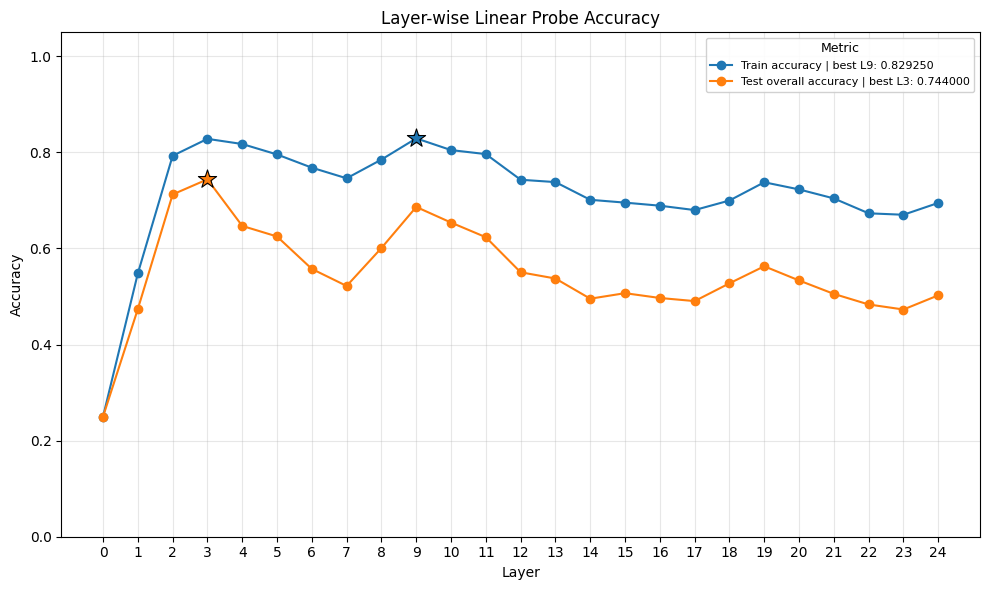

Saved: /content/pilot4_step7_lrab_2500/step7_layerwise_plots/layerwise_train_test_accuracy.png


In [6]:
# ------------------------------------------------------------
# 6. Plot train/test overall accuracy
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6))

# Train accuracy
train_best_layer, train_best_value = get_best_layer_value(
    df,
    "train_accuracy",
)

line_train_acc, = ax.plot(
    df["layer"],
    df["train_accuracy"],
    marker="o",
    label=f"Train accuracy | best L{train_best_layer}: {train_best_value:.6f}",
)

mark_best_point_only(
    ax,
    df,
    "train_accuracy",
    line_train_acc.get_color(),
)

# Test overall accuracy
test_best_layer, test_best_value = get_best_layer_value(
    df,
    "test_overall_accuracy",
)

line_test_acc, = ax.plot(
    df["layer"],
    df["test_overall_accuracy"],
    marker="o",
    label=f"Test overall accuracy | best L{test_best_layer}: {test_best_value:.6f}",
)

mark_best_point_only(
    ax,
    df,
    "test_overall_accuracy",
    line_test_acc.get_color(),
)

ax.set_xlabel("Layer")
ax.set_ylabel("Accuracy")
ax.set_title("Layer-wise Linear Probe Accuracy")
ax.set_xticks(df["layer"])
ax.set_ylim(0.0, 1.05)
ax.grid(True, alpha=0.3)

ax.legend(
    title="Metric",
    loc="upper right",
    fontsize=8,
    title_fontsize=9,
    framealpha=0.9,
)

fig.tight_layout()

acc_path = PLOT_OUTPUT_DIR / "layerwise_train_test_accuracy.png"
fig.savefig(acc_path, dpi=200)
plt.show()

print("Saved:", acc_path)

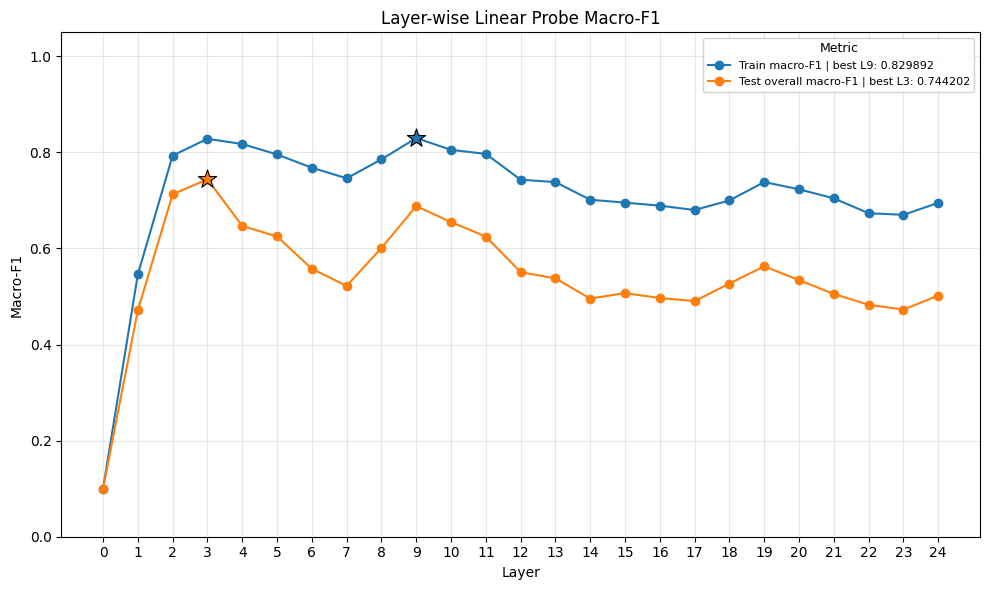

Saved: /content/pilot4_step7_lrab_2500/step7_layerwise_plots/layerwise_train_test_macro_f1.png


In [7]:
# ------------------------------------------------------------
# 7. Plot train/test overall macro-F1
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6))

# Train macro-F1
train_best_layer, train_best_value = get_best_layer_value(
    df,
    "train_macro_f1",
)

line_train_f1, = ax.plot(
    df["layer"],
    df["train_macro_f1"],
    marker="o",
    label=f"Train macro-F1 | best L{train_best_layer}: {train_best_value:.6f}",
)

mark_best_point_only(
    ax,
    df,
    "train_macro_f1",
    line_train_f1.get_color(),
)

# Test overall macro-F1
test_best_layer, test_best_value = get_best_layer_value(
    df,
    "test_overall_macro_f1",
)

line_test_f1, = ax.plot(
    df["layer"],
    df["test_overall_macro_f1"],
    marker="o",
    label=f"Test overall macro-F1 | best L{test_best_layer}: {test_best_value:.6f}",
)

mark_best_point_only(
    ax,
    df,
    "test_overall_macro_f1",
    line_test_f1.get_color(),
)

ax.set_xlabel("Layer")
ax.set_ylabel("Macro-F1")
ax.set_title("Layer-wise Linear Probe Macro-F1")
ax.set_xticks(df["layer"])
ax.set_ylim(0.0, 1.05)
ax.grid(True, alpha=0.3)

ax.legend(
    title="Metric",
    loc="upper right",
    fontsize=8,
    title_fontsize=9,
    framealpha=0.9,
)

fig.tight_layout()

f1_path = PLOT_OUTPUT_DIR / "layerwise_train_test_macro_f1.png"
fig.savefig(f1_path, dpi=200)
plt.show()

print("Saved:", f1_path)

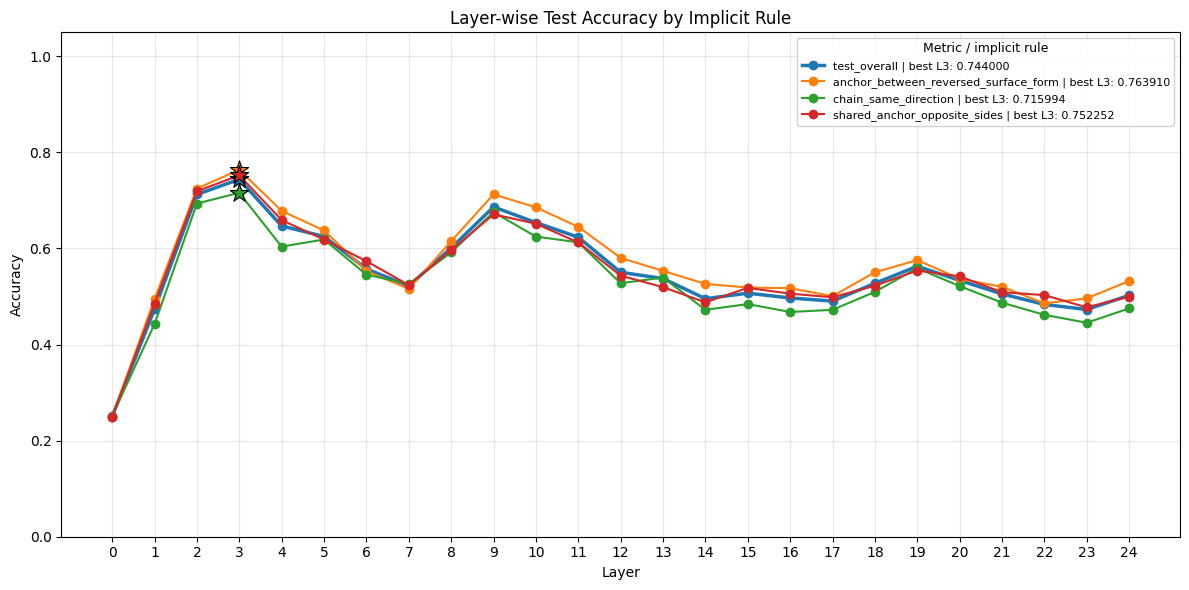

Saved: /content/pilot4_step7_lrab_2500/step7_layerwise_plots/layerwise_test_accuracy_by_implicit_rule.png


In [8]:
# ------------------------------------------------------------
# 8. Plot test accuracy by implicit rule
# ------------------------------------------------------------

rule_accuracy_cols = [
    col for col in df.columns
    if col.endswith("_accuracy")
    and col not in {"train_accuracy", "test_overall_accuracy"}
]

fig, ax = plt.subplots(figsize=(12, 6))

# Overall line
overall_best_layer, overall_best_value = get_best_layer_value(
    df,
    "test_overall_accuracy",
)

line_overall_acc, = ax.plot(
    df["layer"],
    df["test_overall_accuracy"],
    marker="o",
    linewidth=2.5,
    label=f"test_overall | best L{overall_best_layer}: {overall_best_value:.6f}",
)

mark_best_point_only(
    ax,
    df,
    "test_overall_accuracy",
    line_overall_acc.get_color(),
)

# Rule-specific lines
for col in rule_accuracy_cols:
    label = col.replace("_accuracy", "")

    best_layer, best_value = get_best_layer_value(df, col)

    line_rule_acc, = ax.plot(
        df["layer"],
        df[col],
        marker="o",
        label=f"{label} | best L{best_layer}: {best_value:.6f}",
    )

    mark_best_point_only(
        ax,
        df,
        col,
        line_rule_acc.get_color(),
    )

ax.set_xlabel("Layer")
ax.set_ylabel("Accuracy")
ax.set_title("Layer-wise Test Accuracy by Implicit Rule")
ax.set_xticks(df["layer"])
ax.set_ylim(0.0, 1.05)
ax.grid(True, alpha=0.3)

ax.legend(
    title="Metric / implicit rule",
    loc="upper right",
    fontsize=8,
    title_fontsize=9,
    framealpha=0.9,
)

fig.tight_layout()

rule_acc_path = PLOT_OUTPUT_DIR / "layerwise_test_accuracy_by_implicit_rule.png"
fig.savefig(rule_acc_path, dpi=200)
plt.show()

print("Saved:", rule_acc_path)

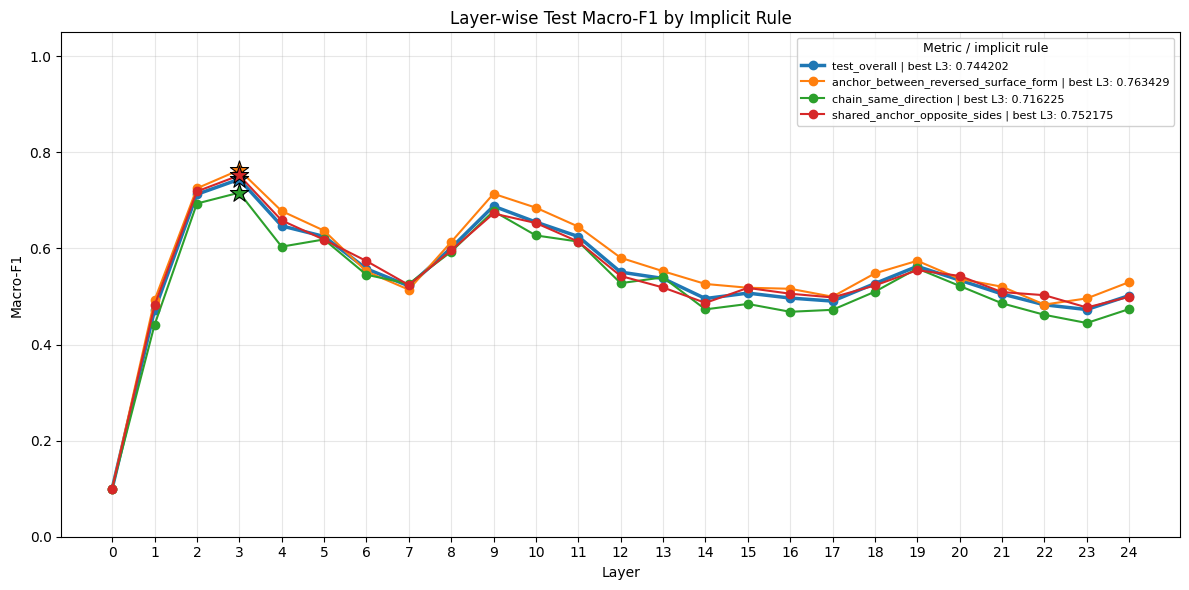

Saved: /content/pilot4_step7_lrab_2500/step7_layerwise_plots/layerwise_test_macro_f1_by_implicit_rule.png


In [9]:
# ------------------------------------------------------------
# 9. Plot test macro-F1 by implicit rule
# ------------------------------------------------------------

rule_f1_cols = [
    col for col in df.columns
    if col.endswith("_macro_f1")
    and col not in {"train_macro_f1", "test_overall_macro_f1"}
]

fig, ax = plt.subplots(figsize=(12, 6))

# Overall line
overall_best_layer, overall_best_value = get_best_layer_value(
    df,
    "test_overall_macro_f1",
)

line_overall_f1, = ax.plot(
    df["layer"],
    df["test_overall_macro_f1"],
    marker="o",
    linewidth=2.5,
    label=f"test_overall | best L{overall_best_layer}: {overall_best_value:.6f}",
)

mark_best_point_only(
    ax,
    df,
    "test_overall_macro_f1",
    line_overall_f1.get_color(),
)

# Rule-specific lines
for col in rule_f1_cols:
    label = col.replace("_macro_f1", "")

    best_layer, best_value = get_best_layer_value(df, col)

    line_rule_f1, = ax.plot(
        df["layer"],
        df[col],
        marker="o",
        label=f"{label} | best L{best_layer}: {best_value:.6f}",
    )

    mark_best_point_only(
        ax,
        df,
        col,
        line_rule_f1.get_color(),
    )

ax.set_xlabel("Layer")
ax.set_ylabel("Macro-F1")
ax.set_title("Layer-wise Test Macro-F1 by Implicit Rule")
ax.set_xticks(df["layer"])
ax.set_ylim(0.0, 1.05)
ax.grid(True, alpha=0.3)

ax.legend(
    title="Metric / implicit rule",
    loc="upper right",
    fontsize=8,
    title_fontsize=9,
    framealpha=0.9,
)

fig.tight_layout()

rule_f1_path = PLOT_OUTPUT_DIR / "layerwise_test_macro_f1_by_implicit_rule.png"
fig.savefig(rule_f1_path, dpi=200)
plt.show()

print("Saved:", rule_f1_path)

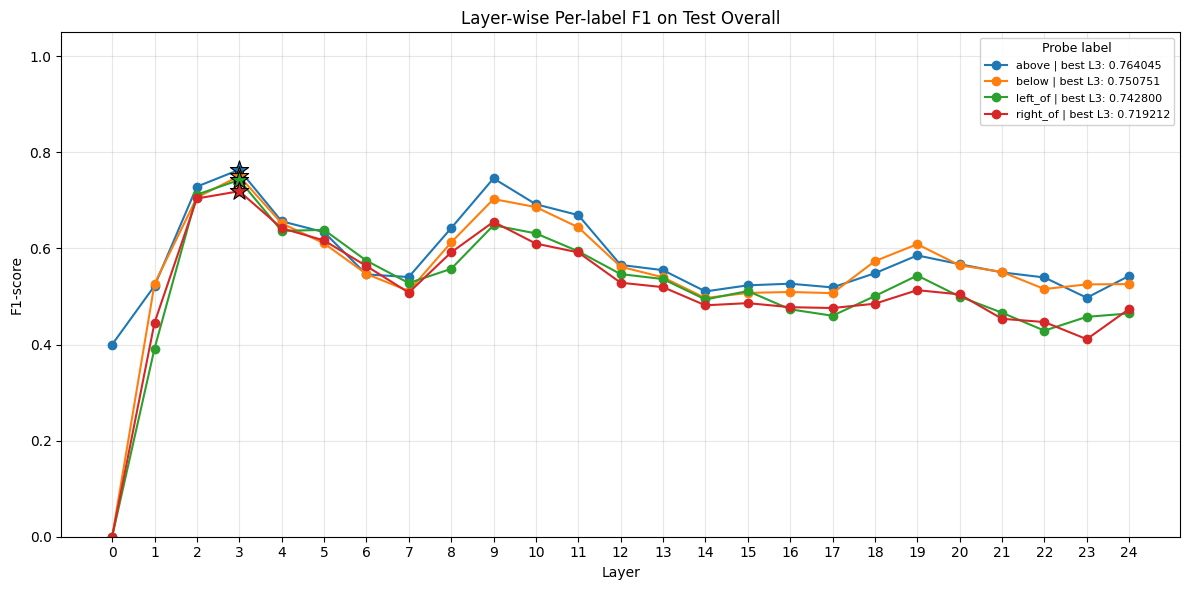

Saved: /content/pilot4_step7_lrab_2500/step7_layerwise_plots/layerwise_test_overall_per_label_f1.png


In [10]:
# ============================================================
# Plot per-label F1 by layer
# ============================================================

def plot_per_label_metric(
    per_label_df: pd.DataFrame,
    *,
    subset_name: str,
    metric: str,
    ylabel: str,
    title: str,
    output_filename: str,
):
    plot_df = per_label_df[
        per_label_df["subset"] == subset_name
    ].copy()

    if plot_df.empty:
        raise ValueError(f"No rows found for subset={subset_name}")

    if metric not in plot_df.columns:
        raise ValueError(f"Metric column not found: {metric}")

    fig, ax = plt.subplots(figsize=(12, 6))

    for label in sorted(plot_df["label"].unique()):
        label_df = plot_df[plot_df["label"] == label].sort_values("layer")

        best_idx = label_df[metric].idxmax()
        best_layer = int(label_df.loc[best_idx, "layer"])
        best_value = float(label_df.loc[best_idx, metric])

        line, = ax.plot(
            label_df["layer"],
            label_df[metric],
            marker="o",
            label=f"{label} | best L{best_layer}: {best_value:.6f}",
        )

        ax.scatter(
            best_layer,
            best_value,
            marker="*",
            s=190,
            color=line.get_color(),
            edgecolor="black",
            linewidth=0.8,
            zorder=6,
        )

    ax.set_xlabel("Layer")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks(sorted(plot_df["layer"].unique()))
    ax.set_ylim(0.0, 1.05)
    ax.grid(True, alpha=0.3)

    ax.legend(
        title="Probe label",
        loc="upper right",
        fontsize=8,
        title_fontsize=9,
        framealpha=0.9,
    )

    fig.tight_layout()

    out_path = PLOT_OUTPUT_DIR / output_filename
    fig.savefig(out_path, dpi=200)
    plt.show()

    print("Saved:", out_path)


plot_per_label_metric(
    per_label_df,
    subset_name="test_overall",
    metric="f1",
    ylabel="F1-score",
    title="Layer-wise Per-label F1 on Test Overall",
    output_filename="layerwise_test_overall_per_label_f1.png",
)

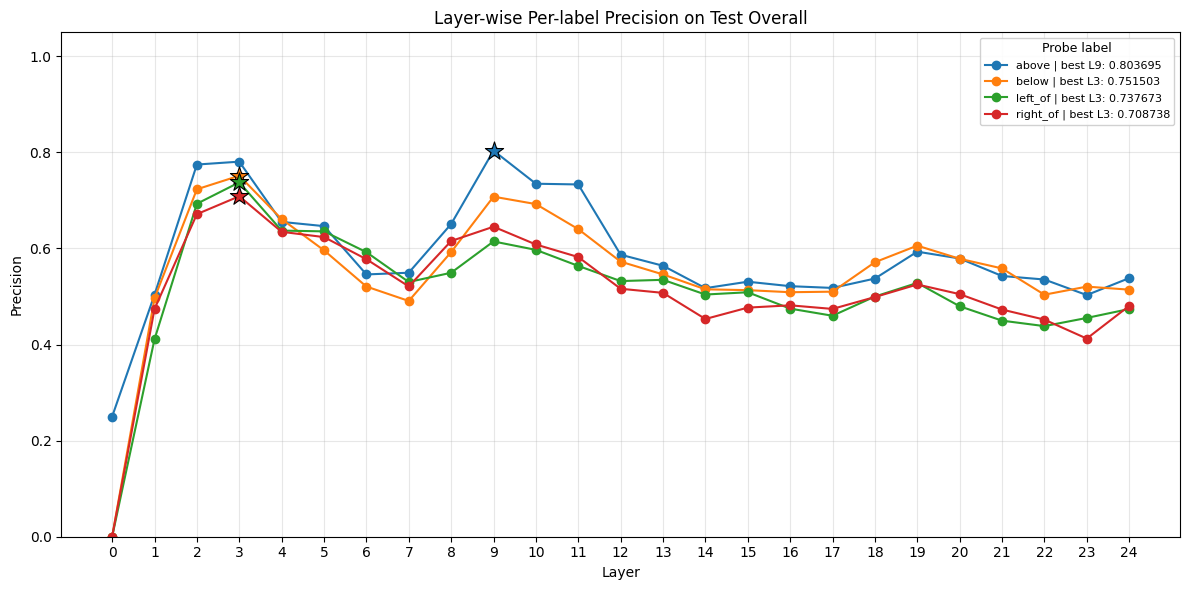

Saved: /content/pilot4_step7_lrab_2500/step7_layerwise_plots/layerwise_test_overall_per_label_precision.png


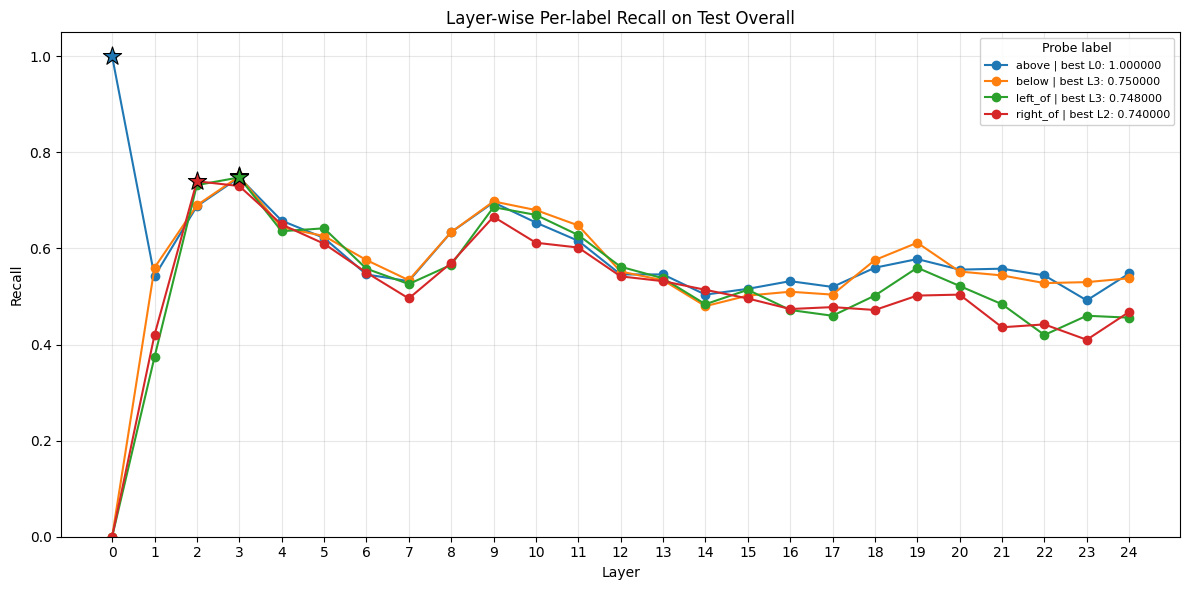

Saved: /content/pilot4_step7_lrab_2500/step7_layerwise_plots/layerwise_test_overall_per_label_recall.png


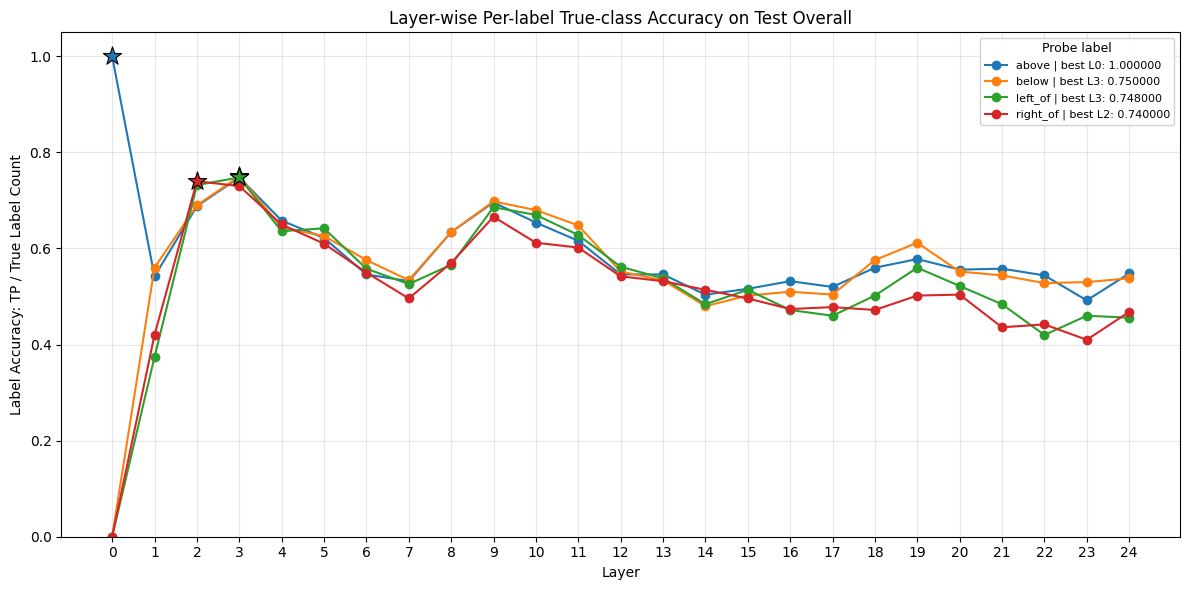

Saved: /content/pilot4_step7_lrab_2500/step7_layerwise_plots/layerwise_test_overall_per_label_true_class_accuracy.png


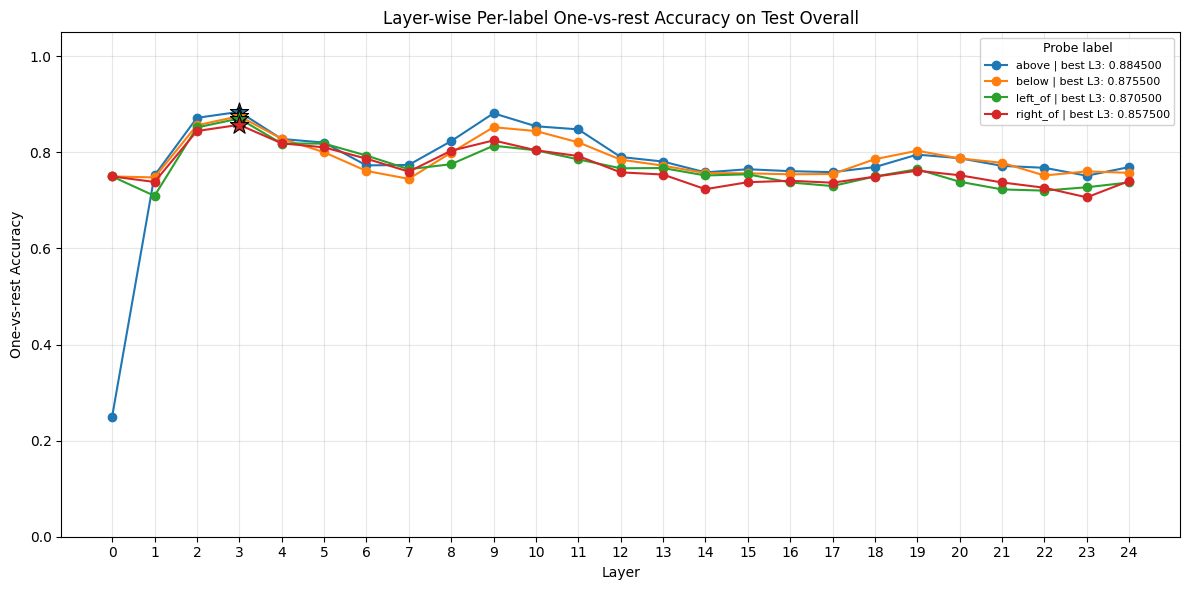

Saved: /content/pilot4_step7_lrab_2500/step7_layerwise_plots/layerwise_test_overall_per_label_one_vs_rest_accuracy.png


In [11]:
# ============================================================
# Plot per-label precision / recall / label accuracy
# ============================================================

plot_per_label_metric(
    per_label_df,
    subset_name="test_overall",
    metric="precision",
    ylabel="Precision",
    title="Layer-wise Per-label Precision on Test Overall",
    output_filename="layerwise_test_overall_per_label_precision.png",
)

plot_per_label_metric(
    per_label_df,
    subset_name="test_overall",
    metric="recall",
    ylabel="Recall",
    title="Layer-wise Per-label Recall on Test Overall",
    output_filename="layerwise_test_overall_per_label_recall.png",
)

if "label_accuracy_true_class" in per_label_df.columns:
    plot_per_label_metric(
        per_label_df,
        subset_name="test_overall",
        metric="label_accuracy_true_class",
        ylabel="Label Accuracy: TP / True Label Count",
        title="Layer-wise Per-label True-class Accuracy on Test Overall",
        output_filename="layerwise_test_overall_per_label_true_class_accuracy.png",
    )

if "one_vs_rest_accuracy" in per_label_df.columns:
    non_null_rows = per_label_df["one_vs_rest_accuracy"].notna().sum()

    if non_null_rows > 0:
        plot_per_label_metric(
            per_label_df,
            subset_name="test_overall",
            metric="one_vs_rest_accuracy",
            ylabel="One-vs-rest Accuracy",
            title="Layer-wise Per-label One-vs-rest Accuracy on Test Overall",
            output_filename="layerwise_test_overall_per_label_one_vs_rest_accuracy.png",
        )

Rule subsets:
- test_rule_anchor_between_reversed_surface_form
- test_rule_chain_same_direction
- test_rule_shared_anchor_opposite_sides


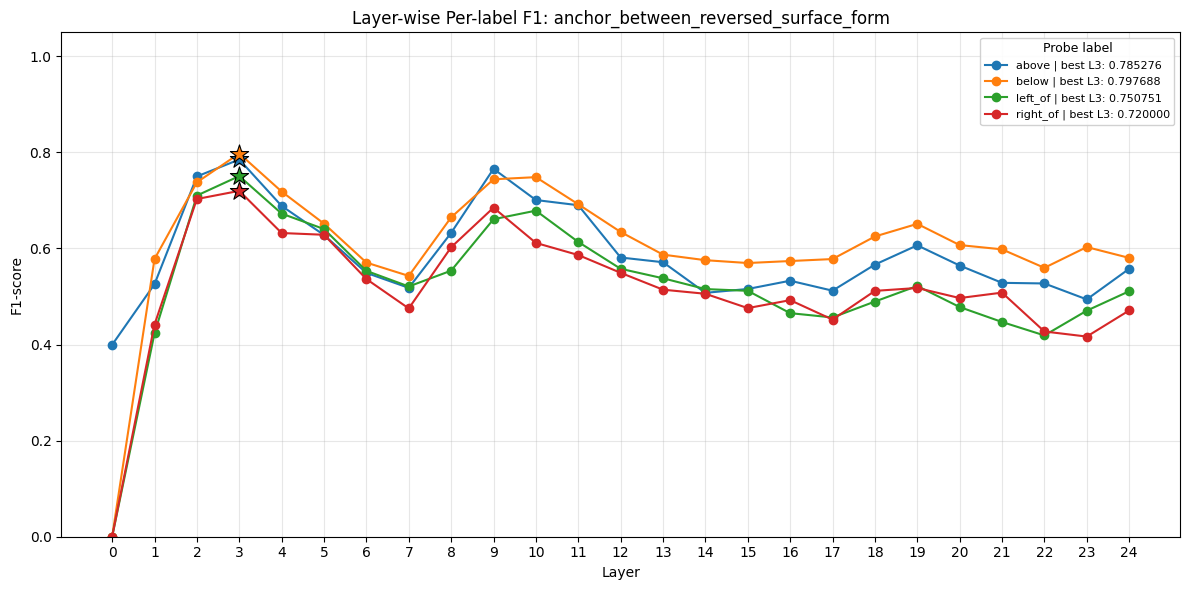

Saved: /content/pilot4_step7_lrab_2500/step7_layerwise_plots/layerwise_test_rule_anchor_between_reversed_surface_form_per_label_f1.png


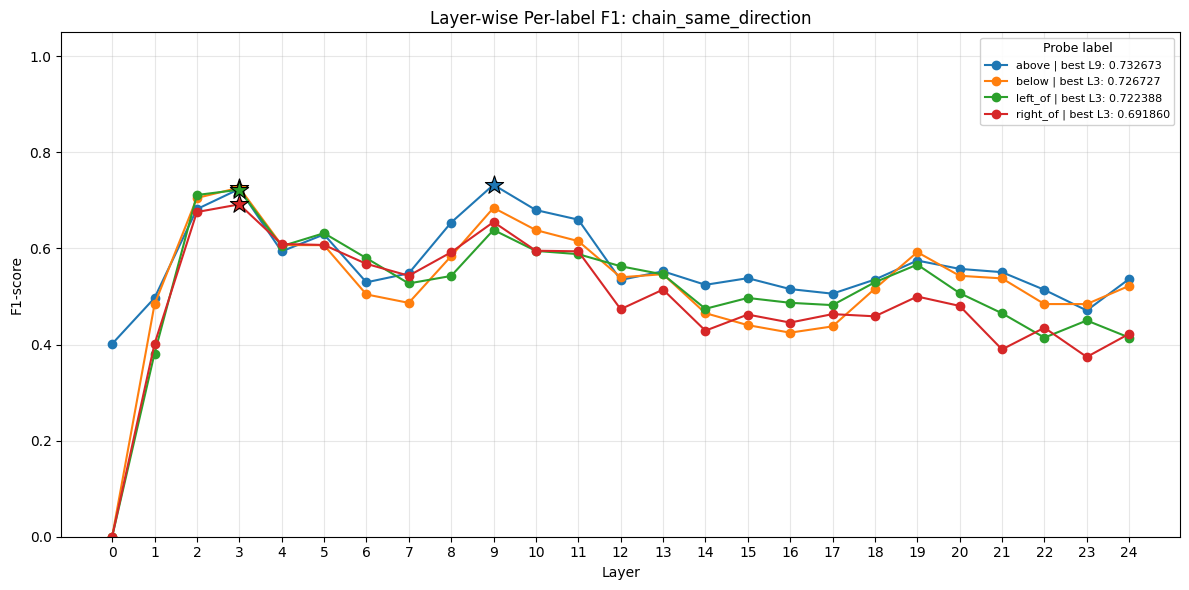

Saved: /content/pilot4_step7_lrab_2500/step7_layerwise_plots/layerwise_test_rule_chain_same_direction_per_label_f1.png


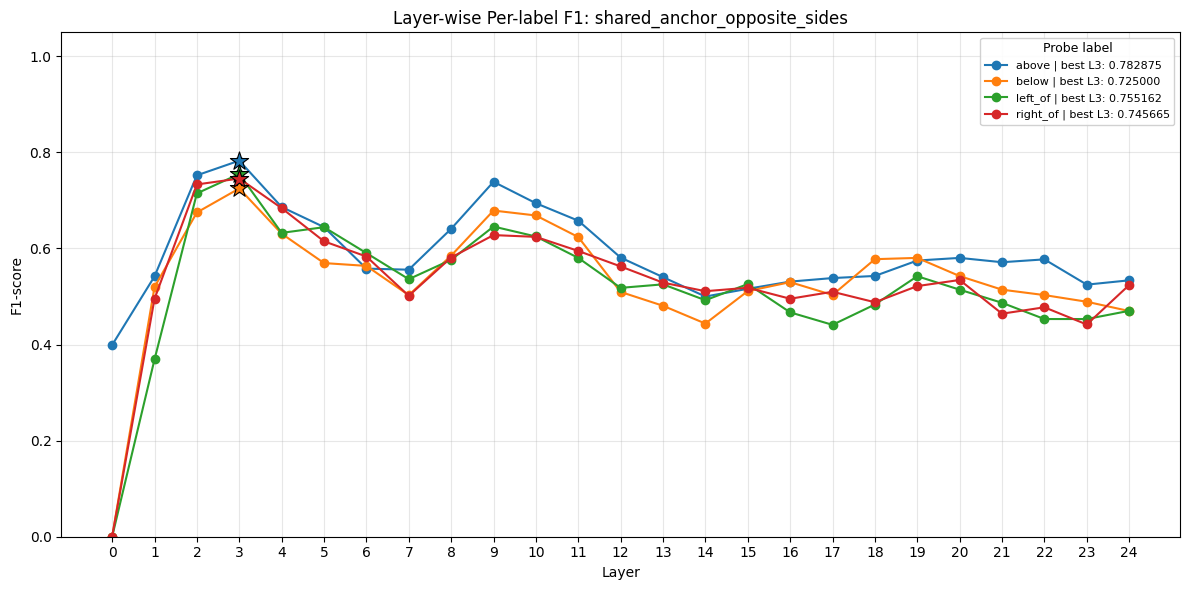

Saved: /content/pilot4_step7_lrab_2500/step7_layerwise_plots/layerwise_test_rule_shared_anchor_opposite_sides_per_label_f1.png


In [12]:
# ============================================================
# Plot per-label F1 for each implicit-rule test subset
# ============================================================

rule_subsets = [
    s for s in sorted(per_label_df["subset"].unique())
    if s.startswith("test_rule_")
]

print("Rule subsets:")
for s in rule_subsets:
    print("-", s)

for subset_name in rule_subsets:
    clean_name = subset_name.replace("test_rule_", "")

    plot_per_label_metric(
        per_label_df,
        subset_name=subset_name,
        metric="f1",
        ylabel="F1-score",
        title=f"Layer-wise Per-label F1: {clean_name}",
        output_filename=f"layerwise_{subset_name}_per_label_f1.png",
    )

In [13]:
# ============================================================
# Save Step7 tables
# ============================================================

# ------------------------------------------------------------
# 1. Save layer-wise overall metrics
# ------------------------------------------------------------

csv_path = PLOT_OUTPUT_DIR / "layerwise_probe_metrics.csv"
df.to_csv(csv_path, index=False)

csv_rounded_path = PLOT_OUTPUT_DIR / "layerwise_probe_metrics_rounded6.csv"
df.round(6).to_csv(csv_rounded_path, index=False)

overall_cols = [
    "layer",
    "train_accuracy",
    "train_macro_f1",
    "test_overall_accuracy",
    "test_overall_macro_f1",
]

overall_csv_path = PLOT_OUTPUT_DIR / "layerwise_overall_metrics_rounded6.csv"
df[overall_cols].round(6).to_csv(overall_csv_path, index=False)


# ------------------------------------------------------------
# 2. Save per-layer per-label metrics
# ------------------------------------------------------------

per_label_csv_path = PLOT_OUTPUT_DIR / "per_layer_per_label_metrics.csv"
per_label_df.to_csv(per_label_csv_path, index=False)

per_label_rounded_csv_path = PLOT_OUTPUT_DIR / "per_layer_per_label_metrics_rounded6.csv"
per_label_df.round(6).to_csv(per_label_rounded_csv_path, index=False)


# ------------------------------------------------------------
# 3. Save wide per-label table for easier manual inspection
# ------------------------------------------------------------

wide_values = [
    "precision",
    "recall",
    "f1",
    "support",
]

if "label_accuracy_true_class" in per_label_df.columns:
    wide_values.append("label_accuracy_true_class")

if "one_vs_rest_accuracy" in per_label_df.columns:
    wide_values.append("one_vs_rest_accuracy")

per_label_wide_df = per_label_df.pivot_table(
    index=["layer", "subset"],
    columns="label",
    values=wide_values,
    aggfunc="first",
)

per_label_wide_df.columns = [
    f"{metric}_{label}"
    for metric, label in per_label_wide_df.columns
]

per_label_wide_df = per_label_wide_df.reset_index()

per_label_wide_csv_path = PLOT_OUTPUT_DIR / "per_layer_per_label_metrics_wide_rounded6.csv"
per_label_wide_df.round(6).to_csv(per_label_wide_csv_path, index=False)


# ------------------------------------------------------------
# 4. Print saved paths
# ------------------------------------------------------------

print("\nSaved full layer-wise metrics CSV:")
print(csv_path)

print("\nSaved rounded layer-wise metrics CSV:")
print(csv_rounded_path)

print("\nSaved overall-only rounded metrics CSV:")
print(overall_csv_path)

print("\nSaved per-layer per-label metrics CSV:")
print(per_label_csv_path)

print("\nSaved rounded per-layer per-label metrics CSV:")
print(per_label_rounded_csv_path)

print("\nSaved wide per-layer per-label metrics CSV:")
print(per_label_wide_csv_path)

print("\nAll plots and tables saved to:")
print(PLOT_OUTPUT_DIR)


Saved full layer-wise metrics CSV:
/content/pilot4_step7_lrab_2500/step7_layerwise_plots/layerwise_probe_metrics.csv

Saved rounded layer-wise metrics CSV:
/content/pilot4_step7_lrab_2500/step7_layerwise_plots/layerwise_probe_metrics_rounded6.csv

Saved overall-only rounded metrics CSV:
/content/pilot4_step7_lrab_2500/step7_layerwise_plots/layerwise_overall_metrics_rounded6.csv

Saved per-layer per-label metrics CSV:
/content/pilot4_step7_lrab_2500/step7_layerwise_plots/per_layer_per_label_metrics.csv

Saved rounded per-layer per-label metrics CSV:
/content/pilot4_step7_lrab_2500/step7_layerwise_plots/per_layer_per_label_metrics_rounded6.csv

Saved wide per-layer per-label metrics CSV:
/content/pilot4_step7_lrab_2500/step7_layerwise_plots/per_layer_per_label_metrics_wide_rounded6.csv

All plots and tables saved to:
/content/pilot4_step7_lrab_2500/step7_layerwise_plots


In [14]:
# ============================================================
# Zip Step7 plot/table results and save to Google Drive
# ============================================================

import shutil
from pathlib import Path

if not PLOT_OUTPUT_DIR.exists():
    raise FileNotFoundError(f"PLOT_OUTPUT_DIR does not exist: {PLOT_OUTPUT_DIR}")

result_files = sorted([p for p in PLOT_OUTPUT_DIR.rglob("*") if p.is_file()])

if not result_files:
    raise FileNotFoundError(f"No result files found in: {PLOT_OUTPUT_DIR}")

print("Files to include:")
for p in result_files:
    print("-", p.relative_to(PLOT_OUTPUT_DIR), "|", round(p.stat().st_size / 1024, 2), "KB")


# ------------------------------------------------------------
# 1. Create local zip
# ------------------------------------------------------------

local_zip_path = shutil.make_archive(
    base_name=str(STEP7_ROOT / "pilot4_synthetic_disorder_lrab_2500_step7_plots"),
    format="zip",
    root_dir=PLOT_OUTPUT_DIR,
)

local_zip_path = Path(local_zip_path)

print("\nCreated local zip:")
print(local_zip_path)


# ------------------------------------------------------------
# 2. Copy zip to Google Drive
# ------------------------------------------------------------

DRIVE_STEP7_OUTPUT_DIR = Path(
    "/content/drive/MyDrive/Colab Notebooks/linear_probe_pilot4/"
    "expB_settingA1_6fps/setting_synthetic/"
    "data_synthetic_disorder_lrab_2500/"
    "step7_plots_lrab_2500"
)

DRIVE_STEP7_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

drive_zip_path = DRIVE_STEP7_OUTPUT_DIR / local_zip_path.name

shutil.copy2(local_zip_path, drive_zip_path)

print("\nSaved Step7 output zip to Google Drive:")
print(drive_zip_path)

Files to include:
- layerwise_overall_metrics_rounded6.csv | 0.92 KB
- layerwise_probe_metrics.csv | 4.8 KB
- layerwise_probe_metrics_rounded6.csv | 2.85 KB
- layerwise_test_accuracy_by_implicit_rule.png | 213.79 KB
- layerwise_test_macro_f1_by_implicit_rule.png | 215.02 KB
- layerwise_test_overall_per_label_f1.png | 211.28 KB
- layerwise_test_overall_per_label_one_vs_rest_accuracy.png | 176.72 KB
- layerwise_test_overall_per_label_precision.png | 224.55 KB
- layerwise_test_overall_per_label_recall.png | 214.6 KB
- layerwise_test_overall_per_label_true_class_accuracy.png | 225.83 KB
- layerwise_test_rule_anchor_between_reversed_surface_form_per_label_f1.png | 233.95 KB
- layerwise_test_rule_chain_same_direction_per_label_f1.png | 222.14 KB
- layerwise_test_rule_shared_anchor_opposite_sides_per_label_f1.png | 222.22 KB
- layerwise_train_test_accuracy.png | 129.71 KB
- layerwise_train_test_macro_f1.png | 129.96 KB
- per_layer_per_label_metrics.csv | 67.16 KB
- per_layer_per_label_metrics